# BÀI KIỂM TRA GIỮA KỲ - BIẾN ĐỔI FOURIER TRONG XỬ LÝ TÍN HIỆU SỐ
**Sinh viên:** Nguyễn Hoàng Minh Thông  
**MSSV:** K25DTCN128  
**Lớp:** D25TXCN04-k
**Ngày thực hiện:** 22/05/2026  

## Câu 1: Thiết lập và tự cài đặt thuật toán Biến đổi Fourier rời rạc (DFT) thủ công

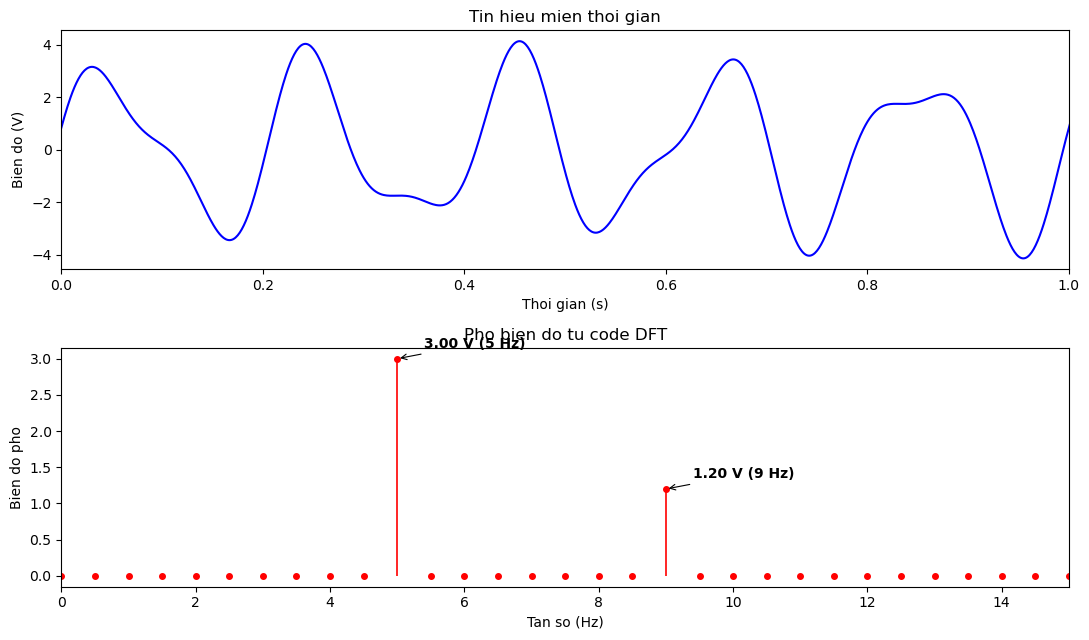

In [15]:

import numpy as np
import matplotlib.pyplot as plt

# 1. thong so tin hieu
fs = 1000  # tan so lay mau
t = np.arange(0, 2, 1/fs)
N = len(t)
# tin hieu theo de bai
x = 3*np.sin(2*np.pi*5*t) + 1.2*np.sin(2*np.pi*9*t + np.pi/4)

# 2. tu viet code DFT bang vong lap 1 tang
fourTime = np.arange(N) / N
fCoefs = np.zeros(N, dtype=complex)
for k in range(N):
    csw = np.exp(-1j * 2 * np.pi * k * fourTime)
    fCoefs[k] = np.sum(x * csw)

# 3. tinh bien do vat ly va nhan doi
ampl = np.abs(fCoefs) / N
ampl[1:N//2] *= 2  # nhan doi pho duong
hz = np.linspace(0, fs/2, N//2 + 1)

# 4. ve do thi
plt.figure(figsize=(11, 6.5))

# ve tin hieu thoi gian
plt.subplot(2, 1, 1)
plt.plot(t, x, 'b')
plt.xlim([0, 1])
plt.xlabel('Thoi gian (s)')
plt.ylabel('Bien do (V)')
plt.title('Tin hieu mien thoi gian')

# ve pho bien do
plt.subplot(2, 1, 2)
markerline, stemlines, baseline = plt.stem(hz, ampl[:len(hz)], basefmt=' ')
plt.setp(stemlines, color='red', linewidth=1.2)
plt.setp(markerline, color='red', markersize=4)
plt.xlim([0, 15])
plt.xlabel('Tan so (Hz)')
plt.ylabel('Bien do pho')
plt.title('Pho bien do tu code DFT')

# chu thich cac dinh de dung ket qua
for f_dinh, a_ky_vong in [(5.0, 3.0), (9.0, 1.2)]:
    vitri = np.argmin(np.abs(hz - f_dinh))
    plt.annotate(f'{ampl[vitri]:.2f} V ({f_dinh:.0f} Hz)', 
                 xy=(hz[vitri], ampl[vitri]),
                 xytext=(hz[vitri]+0.4, ampl[vitri]+0.15),
                 arrowprops=dict(arrowstyle="->", color='black', lw=0.8),
                 weight='bold')

plt.tight_layout()
plt.show()

## Câu 2: So sánh tốc độ thực thi giữa DFT vòng lặp và FFT thư viện


Sai so lon nhat: 1.2169657081671556e-10


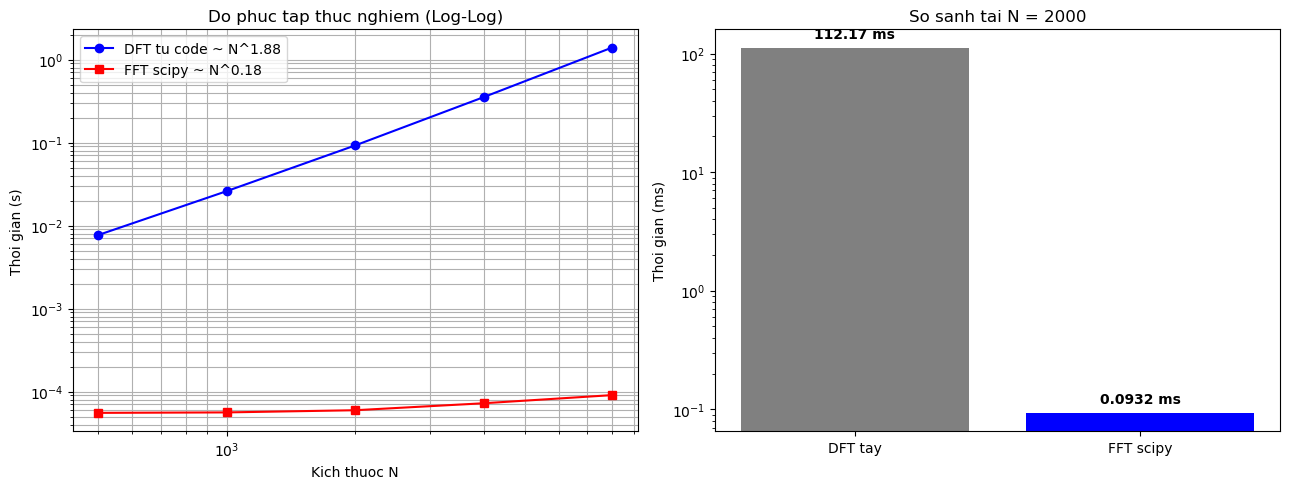

In [16]:

import numpy as np
import scipy.fftpack as sfft
import timeit
import matplotlib.pyplot as plt

# dinh nghia ham DFT dung vong lap don
def dft_loop(x):
    N = len(x)
    fourTime = np.arange(N) / N
    X = np.zeros(N, dtype=complex)
    for k in range(N):
        X[k] = np.sum(x * np.exp(-1j * 2 * np.pi * k * fourTime))
    return X

# 1. do sai so va thoi gian tai N = 2000
np.random.seed(2026)
tin_hieu = np.random.randn(2000)

t1 = timeit.default_timer()
X1 = dft_loop(tin_hieu)
t_dft = timeit.default_timer() - t1

t2 = timeit.default_timer()
X2 = sfft.fft(tin_hieu)
t_fft = timeit.default_timer() - t2

sai_so = np.max(np.abs(X1 - X2))
print("Sai so lon nhat:", sai_so)

# 2. do thoi gian voi cac co mau N khac nhau
Ns = [500, 1000, 2000, 4000, 8000]
t_dft_list = []
t_fft_list = []

for N in Ns:
    data = np.random.randn(N)
    
    # do DFT
    start = timeit.default_timer()
    _ = dft_loop(data)
    t_dft_list.append(timeit.default_timer() - start)
    
    # do FFT
    start = timeit.default_timer()
    _ = sfft.fft(data)
    t_fft_list.append(timeit.default_timer() - start)

# tinh do phuc tap thuc nghiem bang log-log fit
he_so_dft = np.polyfit(np.log(Ns), np.log(t_dft_list), 1)[0]
he_so_fft = np.polyfit(np.log(Ns), np.log(t_fft_list), 1)[0]

# 3. ve do thi
plt.figure(figsize=(13, 5))

# do thi log-log
plt.subplot(1, 2, 1)
plt.loglog(Ns, t_dft_list, 'b-o', label=f'DFT tu code ~ N^{he_so_dft:.2f}')
plt.loglog(Ns, t_fft_list, 'r-s', label=f'FFT scipy ~ N^{he_so_fft:.2f}')
plt.xlabel('Kich thuoc N')
plt.ylabel('Thoi gian (s)')
plt.title('Do phuc tap thuc nghiem (Log-Log)')
plt.legend()
plt.grid(True, which="both")

# ve bieu do cot so sanh tai N=2000
plt.subplot(1, 2, 2)
plt.bar(['DFT tay', 'FFT scipy'], [t_dft*1000, t_fft*1000], color=['gray', 'blue'])
plt.ylabel('Thoi gian (ms)')
plt.yscale('log')
plt.title('So sanh tai N = 2000')
for i, v in enumerate([t_dft*1000, t_fft*1000]):
    plt.text(i, v * 1.2, f'{v:.2f} ms' if v > 1 else f'{v:.4f} ms', ha='center', weight='bold')

plt.tight_layout()
plt.show()

## Câu 3: Khảo sát định lý lấy mẫu Nyquist-Shannon và hiện tượng Aliasing (Gập phổ)


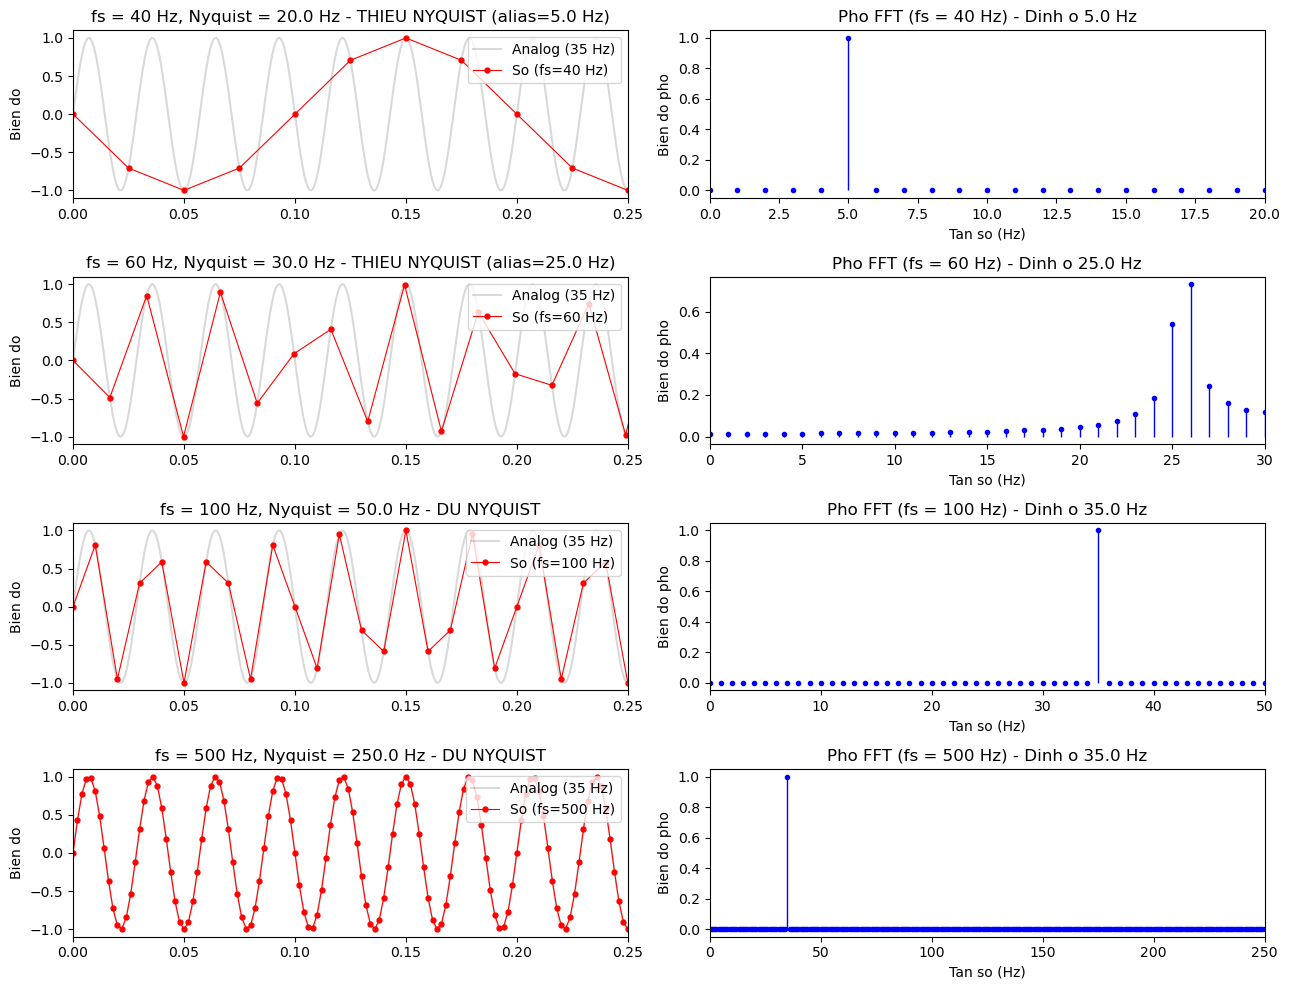

In [17]:

import numpy as np
import matplotlib.pyplot as plt
import scipy.fftpack as sfft

# 1. tao song sin analog gia lap
f_ana = 5000
t_ana = np.arange(0, 1, 1/f_ana)
f_sig = 35
x_ana = np.sin(2*np.pi*f_sig*t_ana)

# 2. lay mau lai voi cac tan so fs khac nhau
fs_list = [40, 60, 100, 500]
plt.figure(figsize=(13, 10))

for idx, fs in enumerate(fs_list):
    buoc = int(round(f_ana / fs))
    x_so = x_ana[::buoc]
    t_so = t_ana[::buoc]
    N_so = len(x_so)
    
    # tinh tan so alias theo ly thuyet
    f_alias_candidates = [abs(f_sig - k*fs) for k in range(-5, 6)]
    f_alias = min([val for val in f_alias_candidates if val <= fs/2])
    
    # ve mien thoi gian
    plt.subplot(len(fs_list), 2, 2*idx + 1)
    plt.plot(t_ana, x_ana, color='black', alpha=0.15, label='Analog (35 Hz)')
    plt.plot(t_so, x_so, 'ro-', markersize=3.5, linewidth=0.8, label=f'So (fs={fs} Hz)')
    plt.xlim([0, 0.25])
    plt.ylabel('Bien do')
    nyq = fs / 2
    tinh_trang = 'DU NYQUIST' if nyq > f_sig else f'THIEU NYQUIST (alias={f_alias:.1f} Hz)'
    plt.title(f"fs = {fs} Hz, Nyquist = {nyq:.1f} Hz - {tinh_trang}")
    plt.legend(loc='upper right')
    
    # tinh FFT tin hieu roi rac
    X_so = np.abs(sfft.fft(x_so)) / N_so
    f_truc = np.linspace(0, fs/2, N_so//2 + 1)
    
    # ve pho bien do
    plt.subplot(len(fs_list), 2, 2*idx + 2)
    markerline, stemlines, baseline = plt.stem(f_truc, 2*X_so[:len(f_truc)], basefmt=' ')
    plt.setp(stemlines, color='blue', linewidth=1.0)
    plt.setp(markerline, color='blue', markersize=3)
    plt.xlabel('Tan so (Hz)')
    plt.ylabel('Bien do pho')
    plt.xlim([0, fs/2])
    plt.title(f"Pho FFT (fs = {fs} Hz) - Dinh o {f_alias:.1f} Hz")

plt.tight_layout()
plt.show()

## Câu 4: Thiết kế bộ lọc thông dải Gauss trong miền tần số


SNR truoc loc: -6.60 dB
SNR sau loc: 23.51 dB


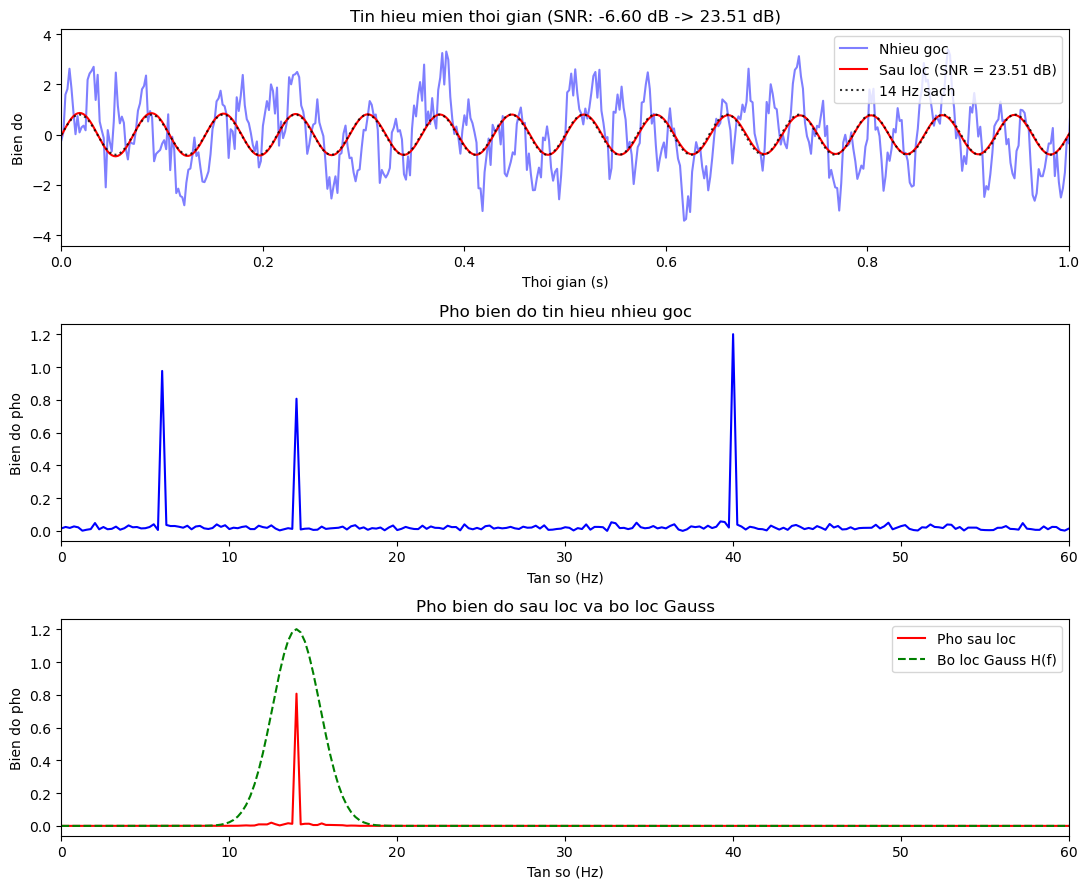

In [18]:

import numpy as np
import scipy.fftpack as sfft
import matplotlib.pyplot as plt

# 1. thiet lap thong so va tao tin hieu nhieu
fs = 500
T = 4
t = np.arange(0, T, 1/fs)
N = len(t)

np.random.seed(2026)
x_sach = np.sin(2*np.pi*14*t)
x_nhieu = (np.sin(2*np.pi*6*t)
           + 0.8*np.sin(2*np.pi*14*t)
           + 1.2*np.sin(2*np.pi*40*t)
           + 0.5*np.random.randn(N))

# ham tinh SNR vat ly
def tinh_snr(tin_hieu, goc):
    sai_so = tin_hieu - goc
    return 10 * np.log10(np.var(goc) / np.var(sai_so))

snr_truoc = tinh_snr(x_nhieu, 0.8*x_sach)

# 2. bien doi FFT sang mien tan so
X = sfft.fft(x_nhieu)
f_full = np.linspace(0, fs, N)

# 3. thiet ke bo loc Gauss doi xung qua Nyquist
f0 = 14
sigma = 2
H = np.exp(-((f_full - f0)/sigma)**2) + np.exp(-((f_full - (fs - f0))/sigma)**2)

# 4. nhan loc va bien doi nguoc IFFT de khoi phuc
Y = X * H
x_loc = np.real(sfft.ifft(Y))

snr_sau = tinh_snr(x_loc, 0.8*x_sach)
print(f"SNR truoc loc: {snr_truoc:.2f} dB")
print(f"SNR sau loc: {snr_sau:.2f} dB")

# 5. ve do thi
f_nua = np.linspace(0, fs/2, N//2 + 1)
X_norm = X / N
Y_norm = Y / N
pho_nhieu = 2*np.abs(X_norm[:len(f_nua)])
pho_nhieu[0] /= 2
pho_loc = 2*np.abs(Y_norm[:len(f_nua)])
pho_loc[0] /= 2

plt.figure(figsize=(11, 9))

# do thi thoi gian
plt.subplot(3, 1, 1)
plt.plot(t, x_nhieu, color='blue', alpha=0.5, label='Nhieu goc')
plt.plot(t, x_loc, color='red', linewidth=1.5, label=f'Sau loc (SNR = {snr_sau:.2f} dB)')
plt.plot(t, 0.8*x_sach, 'k:', alpha=0.8, label='14 Hz sach')
plt.xlim([0, 1])
plt.xlabel('Thoi gian (s)')
plt.ylabel('Bien do')
plt.title(f'Tin hieu mien thoi gian (SNR: {snr_truoc:.2f} dB -> {snr_sau:.2f} dB)')
plt.legend(loc='upper right')

# pho truoc khi loc
plt.subplot(3, 1, 2)
plt.plot(f_nua, pho_nhieu, 'b')
plt.xlim([0, 60])
plt.xlabel('Tan so (Hz)')
plt.ylabel('Bien do pho')
plt.title('Pho bien do tin hieu nhieu goc')

# pho sau khi loc va dap ung bo loc
plt.subplot(3, 1, 3)
plt.plot(f_nua, pho_loc, 'r', label='Pho sau loc')
plt.plot(f_nua, H[:len(f_nua)] * np.max(pho_nhieu), 'g--', label='Bo loc Gauss H(f)')
plt.xlim([0, 60])
plt.xlabel('Tan so (Hz)')
plt.ylabel('Bien do pho')
plt.title('Pho bien do sau loc va bo loc Gauss')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

## Câu 5: Phân tích thời gian - tần số với Biến đổi Fourier thời gian ngắn (STFT)


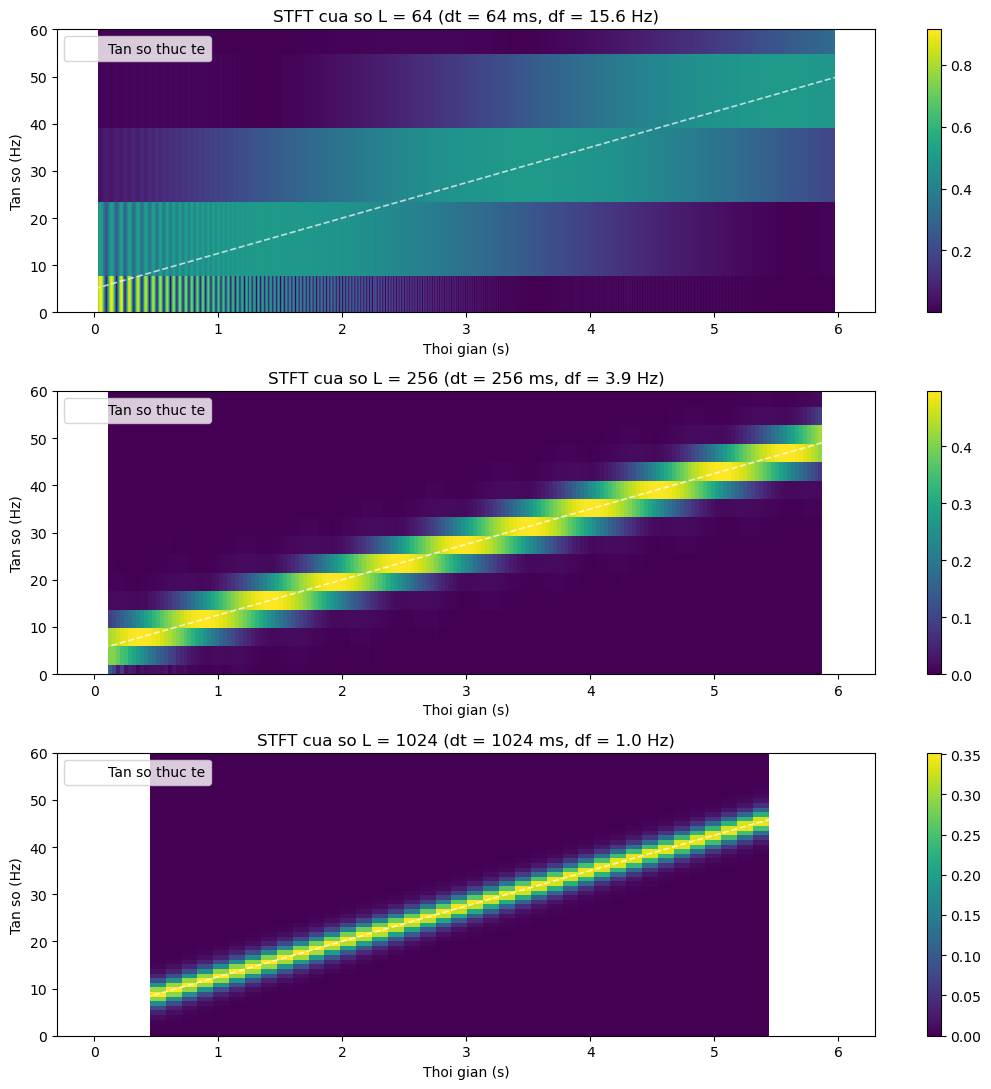

In [19]:
# --- CÂU 5 ---
import numpy as np
import scipy.fftpack as sfft
import matplotlib.pyplot as plt

# 1. sinh tin hieu chirp
fs = 1000
T = 6
t = np.arange(0, T, 1/fs)
N = len(t)
f_ch = np.linspace(5, 50, N)
# sinh song chirp bang cong thuc tich phan pha chuan xac
tin_hieu = np.sin(2 * np.pi * (5 * t + 0.5 * 7.5 * t**2))

# 2. viet ham STFT dung vong lap
def tu_stft(x, L, hop):
    # cua so Hann
    win = 0.5 * (1 - np.cos(2 * np.pi * np.arange(L) / (L - 1)))
    M = (len(x) - L) // hop + 1
    out = np.zeros((L, M), dtype=complex)
    for m in range(M):
        doan = x[m*hop : m*hop + L]
        out[:, m] = sfft.fft(win * doan) / L
    return out

plt.figure(figsize=(11, 11))
cua_so = [64, 256, 1024]

for idx, L in enumerate(cua_so):
    hop = L // 8
    S = tu_stft(tin_hieu, L, hop)
    f_truc = np.linspace(0, fs/2, L//2 + 1)
    t_truc = (np.arange(S.shape[1])*hop + L/2) / fs
    
    anh_spectrogram = 2 * np.abs(S[:L//2+1, :])
    
    plt.subplot(3, 1, idx + 1)
    pcm = plt.pcolormesh(t_truc, f_truc, anh_spectrogram, shading='auto', cmap='viridis')
    plt.plot(t, f_ch, 'w--', linewidth=1.2, alpha=0.7, label='Tan so thuc te')
    plt.ylim([0, 60])
    plt.xlabel('Thoi gian (s)')
    plt.ylabel('Tan so (Hz)')
    plt.title(f"STFT cua so L = {L} (dt = {L/fs*1000:.0f} ms, df = {fs/L:.1f} Hz)")
    plt.legend(loc='upper left')
    plt.colorbar(pcm)

plt.tight_layout()
plt.show()

## Câu 6: Phân tích phổ tín hiệu Điện não đồ (EEG) thực tế


Nang luong tuong doi cac bang tan:
  Delta  ( 0.5 -  4.0 Hz): 43.44%
  Theta  ( 4.0 -  8.0 Hz):  8.13%
  Alpha  ( 8.0 - 13.0 Hz): 17.98%
  Beta   (13.0 - 30.0 Hz):  8.28%
  Gamma  (30.0 - 70.0 Hz): 10.73%


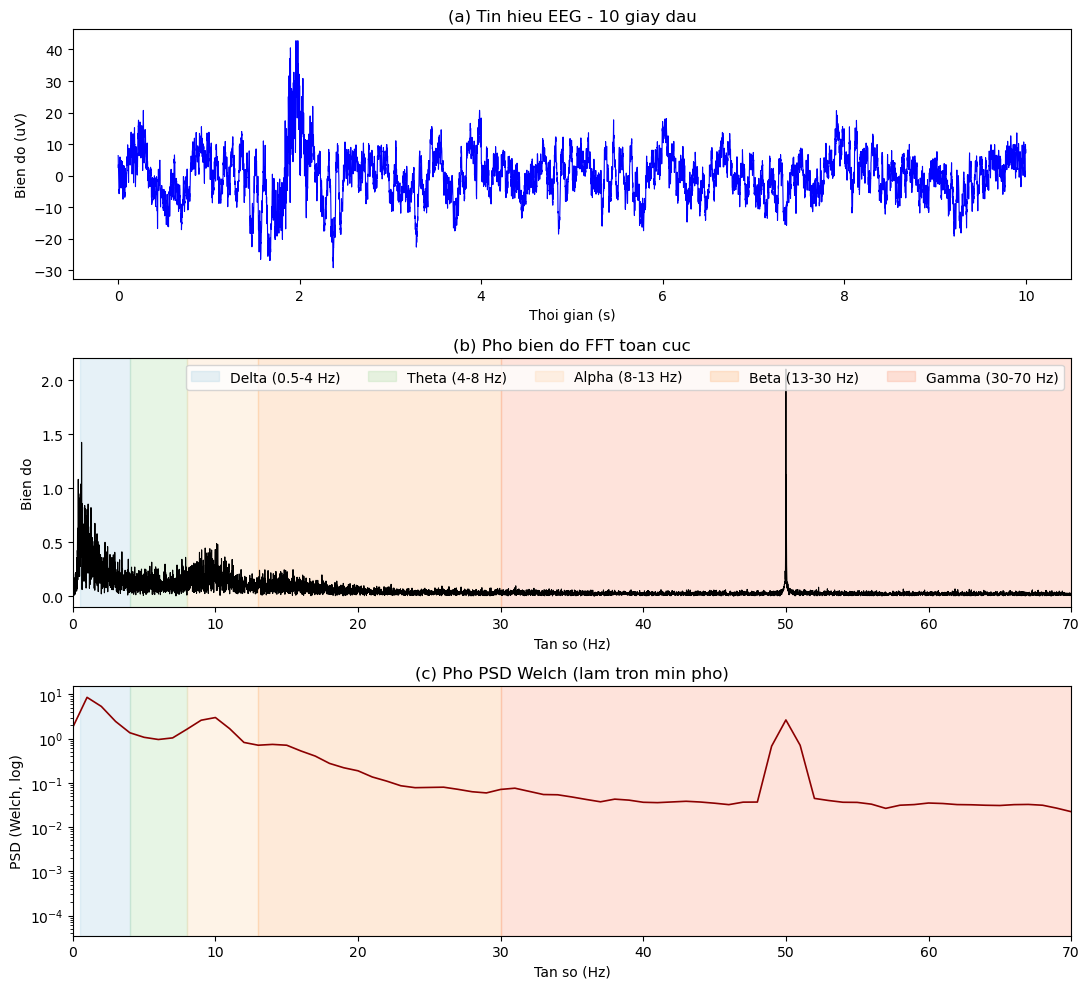

In [20]:

import numpy as np
import scipy.fftpack as sfft
import scipy.signal as signal
import scipy.io as sio
import matplotlib.pyplot as plt
import os

# 1. doc file du lieu eeg
duong_dan = r"D:\HocTap_PTIT\XuLyTinHieuSo\Fourier_apps\EEGrestingState.mat"
if not os.path.exists(duong_dan):
    raise FileNotFoundError(f"Khong tim thay file {duong_dan}!")

data_mat = sio.loadmat(duong_dan)
eeg_data = data_mat['eegdata'].flatten()
fs_eeg = int(data_mat['srate'][0, 0])
N = len(eeg_data)
t = np.arange(N) / fs_eeg

# 2. tinh pho FFT toan cuc
X = sfft.fft(eeg_data) / N
f_eeg = np.linspace(0, fs_eeg/2, N//2 + 1)
bien_do = 2 * np.abs(X[:len(f_eeg)])
bien_do[0] /= 2

# 3. tinh pho PSD bang phuong phap Welch lam min
f_w, P_w = signal.welch(eeg_data, fs_eeg, nperseg=fs_eeg, noverlap=fs_eeg//2)

# 5 bang tan song nao y sinh
bands = {
    'Delta': (0.5, 4, '#9ecae1'),
    'Theta': (4, 8, '#a1d99b'),
    'Alpha': (8, 13, '#fdd0a2'),
    'Beta': (13, 30, '#fdae6b'),
    'Gamma': (30, 70, '#fc9272'),
}

# tinh toan nang luong tuong doi
total_e = np.sum(bien_do**2)
print("Nang luong tuong doi cac bang tan:")
for ten, (lo, hi, _) in bands.items():
    mask = (f_eeg >= lo) & (f_eeg < hi)
    e_band = np.sum(bien_do[mask]**2)
    print(f"  {ten:6s} ({lo:4.1f} - {hi:4.1f} Hz): {100*e_band/total_e:5.2f}%")

# 4. ve cac do thi
plt.figure(figsize=(11, 10))

# ve 10 giay tin hieu dau
plt.subplot(3, 1, 1)
plt.plot(t[:10*fs_eeg], eeg_data[:10*fs_eeg], color='blue', linewidth=0.8)
plt.xlabel('Thoi gian (s)')
plt.ylabel('Bien do (uV)')
plt.title('(a) Tin hieu EEG - 10 giay dau')

# ve FFT toan cuc to mau
plt.subplot(3, 1, 2)
for ten, (lo, hi, c) in bands.items():
    plt.axvspan(lo, hi, alpha=0.25, color=c, label=f"{ten} ({lo}-{hi} Hz)")
plt.plot(f_eeg, bien_do, color='black', linewidth=0.8)
plt.xlim([0, 70])
plt.xlabel('Tan so (Hz)')
plt.ylabel('Bien do')
plt.title('(b) Pho bien do FFT toan cuc')
plt.legend(ncol=5, loc='upper right')

# ve Welch PSD
plt.subplot(3, 1, 3)
for ten, (lo, hi, c) in bands.items():
    plt.axvspan(lo, hi, alpha=0.25, color=c)
plt.semilogy(f_w, P_w, color='darkred', linewidth=1.2)
plt.xlim([0, 70])
plt.xlabel('Tan so (Hz)')
plt.ylabel('PSD (Welch, log)')
plt.title('(c) Pho PSD Welch (lam tron min pho)')

plt.tight_layout()
plt.show()

## Câu 7: Vận dụng Biến đổi Fourier hai chiều (2D DFT) xử lý ảnh tần số không gian


Sigma = 0.05: Low-pass RMSE = 24.79
Sigma = 0.10: Low-pass RMSE = 17.92
Sigma = 0.20: Low-pass RMSE = 12.34


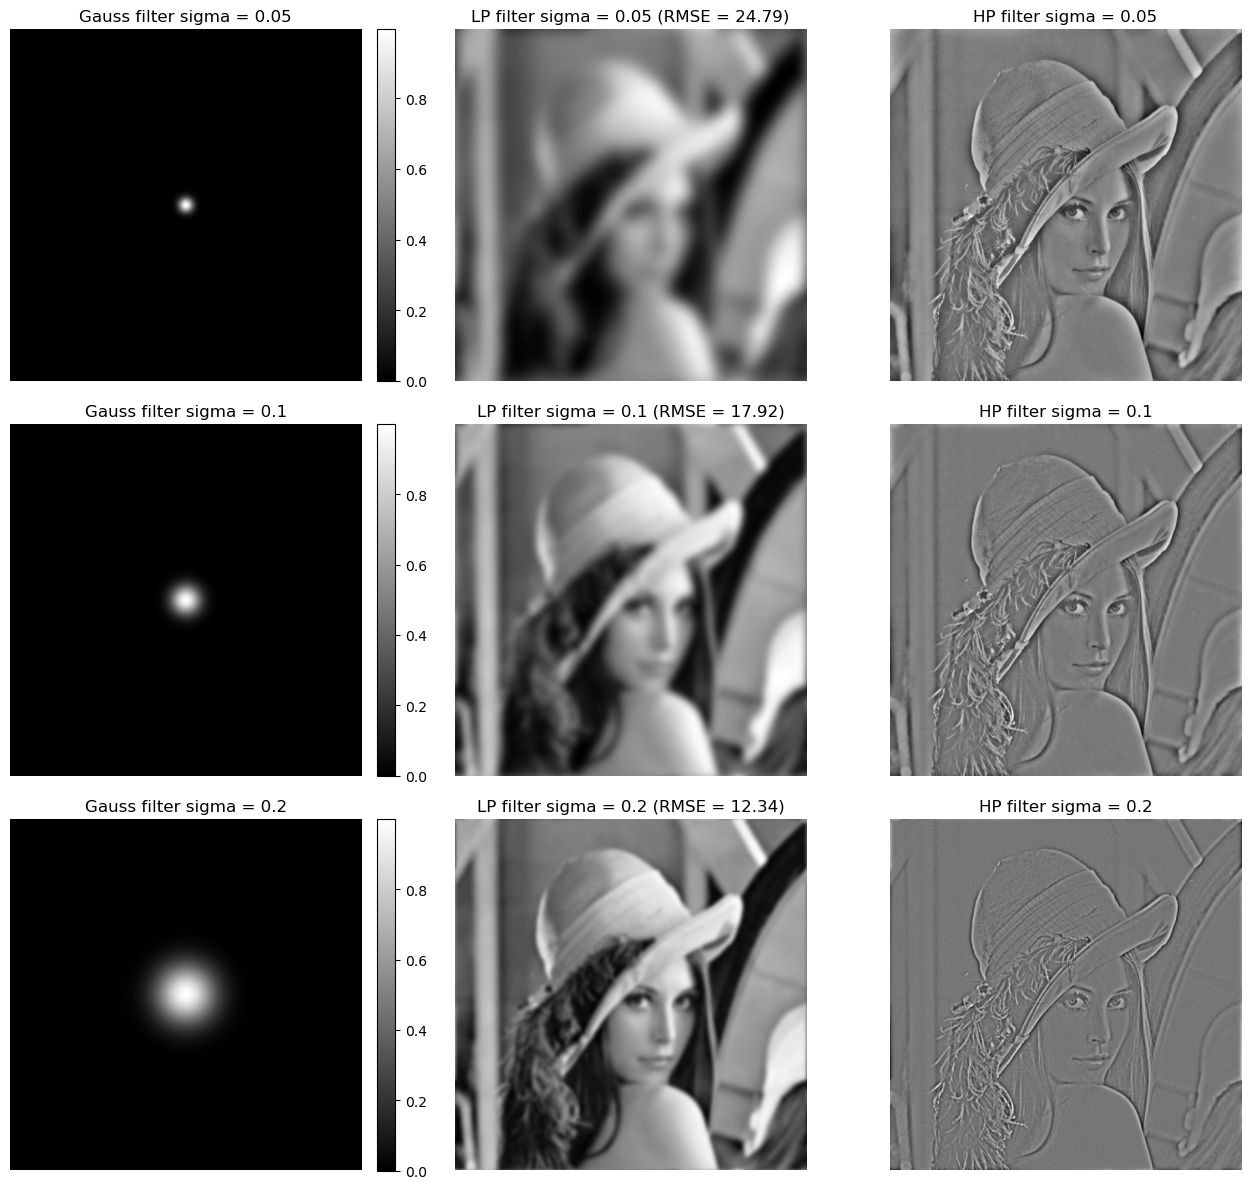

In [21]:

import numpy as np
import scipy.fftpack as sfft
import matplotlib.pyplot as plt
from scipy import stats
from PIL import Image
import os

# 1. doc anh muc xam Lenna
file_anh = r"D:\HocTap_PTIT\XuLyTinHieuSo\Fourier_apps\Lenna.png"
if not os.path.exists(file_anh):
    raise FileNotFoundError(f"Khong tim thay anh {file_anh}!")

anh_goc = np.array(Image.open(file_anh).convert('L'), dtype=float)

# 2. bien doi FFT 2D va dich tam
F = sfft.fftshift(sfft.fft2(anh_goc))

# 3. dung luoi toa do zscore doi xung de tao mat na Gauss
x_coord = stats.zscore(np.arange(anh_goc.shape[1]))
y_coord = stats.zscore(np.arange(anh_goc.shape[0]))
X, Y = np.meshgrid(x_coord, y_coord)

sigmas = [0.05, 0.10, 0.20]
plt.figure(figsize=(13, 12))

for idx, sigma in enumerate(sigmas):
    # thiet ke mat na loc Gauss 2D
    G = np.exp(-(X**2 + Y**2) / (2*sigma**2))
    
    # loc thong thap va bien doi nguoc IFFT 2D
    F_lp = F * G
    anh_lp = np.real(sfft.ifft2(sfft.ifftshift(F_lp)))
    
    # loc thong cao va bien doi nguoc
    F_hp = F * (1 - G)
    anh_hp = np.real(sfft.ifft2(sfft.ifftshift(F_hp)))
    
    # tinh sai so RMSE giua anh goc va anh sau loc thong thap
    rmse_val = np.sqrt(np.mean((anh_goc - anh_lp)**2))
    print(f"Sigma = {sigma:.2f}: Low-pass RMSE = {rmse_val:.2f}")
    
    # ve mat na loc Gauss
    plt.subplot(len(sigmas), 3, 3*idx + 1)
    im0 = plt.imshow(G, cmap='gray')
    plt.title(f"Gauss filter sigma = {sigma}")
    plt.colorbar(im0, fraction=0.046, pad=0.04)
    plt.axis('off')
    
    # ve anh sau loc thong thap
    plt.subplot(len(sigmas), 3, 3*idx + 2)
    plt.imshow(anh_lp, cmap='gray')
    plt.title(f"LP filter sigma = {sigma} (RMSE = {rmse_val:.2f})")
    plt.axis('off')
    
    # ve anh sau loc thong cao
    plt.subplot(len(sigmas), 3, 3*idx + 3)
    plt.imshow(anh_hp, cmap='gray')
    plt.title(f"HP filter sigma = {sigma}")
    plt.axis('off')

plt.tight_layout()
plt.show()